# PHASE1: Chargement,Exploration, Nettoyage et Préparation des Données

Cette phase permet de charger vos trois fichiers CSV, de nettoyer les structures de données complexes (les listes stockées sous forme de chaînes de caractères) et de restructurer le tout pour créer l'historique de visionnage au format demandé.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from scipy.cluster.vq import kmeans, vq
import ast

#Chargement et nettoyage des données

df_profils = pd.read_csv("./data/profils_utilisateurs.csv")

#convertir les colonnes en des listes
df_profils['preferences'] = df_profils['preferences'].apply(ast.literal_eval)
df_profils['watch_history'] = df_profils['watch_history'].apply(ast.literal_eval)

#calculer la médiane de l'âge pour les valeurs valides
age_median = df_profils.loc[(df_profils['age'] >= 15) & (df_profils['age'] <= 65), 'age'].median()

#remplacer les valeurs manquantes ou aberrantes par la médiane
df_profils.loc[(df_profils['age'].isna()) | (df_profils['age'] < 15) | (df_profils['age'] > 65), 'age'] = age_median
#convertir la colonne 'age' en entier
df_profils['age'] = df_profils['age'].astype(int)

#remplacer les préférences manquantes ou vides par une liste contenant "drame"
df_profils['preferences'] = df_profils['preferences'].apply(lambda x: x if isinstance(x, list) and len(x) > 0 else ["drame"])

#filtrer les historiques de visionnage pour ne conserver que les films avec une note entre 1 et 5, et remplacer les genres manquants par "indéfini"
def filtrer_et_nettoyer_historique(historique):
    if not isinstance(historique, list):
        return []
        
    historique_propre = []
    for film in historique:
        if film['rating'] < 1 or film['rating'] > 5:
            continue
            
        if film['genre'] is None:
            film['genre'] = "indéfini"
            
        historique_propre.append(film)
        
    return historique_propre

df_profils['watch_history'] = df_profils['watch_history'].apply(filtrer_et_nettoyer_historique)

#Création des structures de données pour les utilisateurs et les historiques de visionnage
utilisateurs_structures = {}
dictionnaire_historiques = {}

for index, ligne in df_profils.iterrows():
    user_id = index + 1 
    
    utilisateurs_structures[user_id] = {
        "name": ligne['name'],
        "age": ligne['age'],
        "preferences": ligne['preferences'],
        "watch_history": ligne['watch_history']
    }
    
    dictionnaire_historiques[user_id] = ligne['watch_history']

#parcourir les historiques de visionnage pour construire un catalogue de films avec leurs genres
catalogue_films = {}
for hist in df_profils['watch_history']:
    for f in hist:
        titre = f['movie']
        if titre not in catalogue_films:
            catalogue_films[titre] = f['genre']

# PHASE2 : Construction du moteur de recommandation

### Filtrage basé sur le contenu

Cet algorithme analyse les caractéristiques des films (comme les genres) qu'un utilisateur a déjà bien notés afin de lui recommander des titres similaires présents dans le catalogue. Il permet ainsi de générer des propositions personnalisées basées directement sur la fidélité aux goûts passés de l'individu.



In [ ]:
#Si tu as aimé des films d'action, je te propose d'autres films d'action.
def recommander_par_contenu(id_cible, donnees_utilisateurs, catalogue, top_n=5):
    if id_cible not in donnees_utilisateurs:
        return []
    
    profil = donnees_utilisateurs[id_cible]
    historique = profil["watch_history"]
    films_vus = {f["movie"] for f in historique}
    
    genres_aimes = {}
    for f in historique:
        if f["rating"] >= 4.0:
            genres = f["genre"] if isinstance(f["genre"], list) else [f["genre"]]
            for g in genres:
                genres_aimes[g] = genres_aimes.get(g, 0) + 1
                
    if not genres_aimes:
        for g in profil["preferences"]:
            genres_aimes[g] = 1
            
    recommandations = []
    for titre_film, genres_film in catalogue.items():
        if titre_film in films_vus:
            continue
            
        liste_g_film = genres_film if isinstance(genres_film, list) else [genres_film]
        score = sum(genres_aimes.get(g, 0) for g in liste_g_film)
        
        if score > 0:
            recommandations.append((titre_film, liste_g_film, score))
            
    recommandations.sort(key=lambda x: x[2], reverse=True)
    
    print(f"RECOMMANDATIONS CONTENU POUR {profil['name'].upper()}")
    film_reference = next((f["movie"] for f in historique if f["rating"] >= 4.0), "vos préférences")
    print(f"Basé sur votre intérêt pour '{film_reference}', voici nos suggestions :\n")
    
    for i, (titre, genres, score) in enumerate(recommandations[:top_n]):
        print(f"{i+1}. {titre} (Genres: {', '.join(genres)}) - Score : {score}")
        
    return recommandations[:top_n]

recommander_par_contenu(1, utilisateurs_structures, catalogue_films)

RECOMMANDATIONS CONTENU POUR NOAH
Basé sur votre intérêt pour 'The Matrix', voici nos suggestions :

1. Interstellar (Genres: sci-fi) - Score : 1
2. Inception (Genres: sci-fi) - Score : 1


[('Interstellar', ['sci-fi'], 1), ('Inception', ['sci-fi'], 1)]

### Filtrage collaboratif via la Corrélation de Pearson

Cette méthode mesure la similarité mathématique entre les profils de notation des différents utilisateurs à l'aide de la fonction scipy.stats.pearsonr. Elle permet de prédire les préférences d'un utilisateur cible en lui suggérant des films fortement appréciés par des "voisins" ayant des habitudes de consommation identiques.

In [ ]:
# 1. Pivotage des données en matrice Utilisateurs x Films
lignes_notations = []
for user_id, profil in utilisateurs_structures.items():
    for f in profil['watch_history']:
        lignes_notations.append({
            'userId': user_id,
            'movieTitle': f['movie'],
            'rating': f['rating']
        })

ratings_df = pd.DataFrame(lignes_notations)
# 1. Pivotage des données en matrice Utilisateurs x Films
lignes_notations = []
for user_id, profil in utilisateurs_structures.items():
    for f in profil['watch_history']:
        lignes_notations.append({
            'userId': user_id,
            'movieTitle': f['movie'],
            'rating': f['rating']
        })

ratings_df = pd.DataFrame(lignes_notations)

#Créer une matrice Utilisateurs × Films
matrice_notes = ratings_df.pivot_table(index='userId', columns='movieTitle', values='rating', aggfunc='mean')
# 2. Fonction de calcul Pearson
def recommander_par_pearson(id_cible, matrice, donnees_utilisateurs, top_n=5):
    if id_cible not in matrice.index:
        return []
    
    notes_cible = matrice.loc[id_cible]
    similarites = []
    
    for autre_id in matrice.index:
        if autre_id == id_cible:
            continue
            
        notes_autre = matrice.loc[autre_id]
        masque_commun = notes_cible.notna() & notes_autre.notna()
        
        if masque_commun.sum() < 2:
            continue
        
        #Calculer le coefficient de Pearson pour les films notés en commun
        score_pearson, _ = pearsonr(notes_cible[masque_commun], notes_autre[masque_commun])
        if not np.isnan(score_pearson) and score_pearson > 0:
            similarites.append((autre_id, score_pearson))
    #Trier les utilisateurs similaires par ordre décroissant de similarité        
    similarites.sort(key=lambda x: x[1], reverse=True)
    #Calculer les recommandations basées sur les utilisateurs similaires
    films_vus = set(matrice.columns[notes_cible.notna()])
    suggestions = {}
    total_sim = {}
    #Prendre en compte les 5 utilisateurs les plus similaires pour faire des recommandations
    for autre_id, sim in similarites[:5]:
        notes_autre = matrice.loc[autre_id]
        for film in matrice.columns:
            if film in films_vus or pd.isna(notes_autre[film]):
                continue
            suggestions[film] = suggestions.get(film, 0) + notes_autre[film] * sim
            total_sim[film] = total_sim.get(film, 0) + sim
    #Calculer le score final pour chaque film recommandé        
    recommandations_collaboratives = []
    for film, score_cumule in suggestions.items():
        score_final = score_cumule / total_sim[film]
        recommandations_collaboratives.append((film, score_final))
    #Trier les recommandations par score décroissant    
    recommandations_collaboratives.sort(key=lambda x: x[1], reverse=True)
    #Afficher les recommandations
    print(f"\nRECOMMANDATIONS COLLABORATIVES (PEARSON) POUR {donnees_utilisateurs[id_cible]['name'].upper()} :")
    for i, (film, score) in enumerate(recommandations_collaboratives[:top_n]):
        print(f"{i+1}. {film} - Note prédite : {score:.2f}/5")
        
    return recommandations_collaboratives[:top_n]

# Test du filtrage collaboratif
reco_pearson = recommander_par_pearson(1, matrice_notes, utilisateurs_structures)

C:\Users\Debohi\AppData\Local\Temp\ipykernel_18032\805825033.py:43: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  score_pearson, _ = pearsonr(notes_cible[masque_commun], notes_autre[masque_commun])



RECOMMANDATIONS COLLABORATIVES (PEARSON) POUR ELIJAH :
1. The Dark Knight - Note prédite : 5.00/5
2. Inception - Note prédite : 4.00/5
3. Shutter Island - Note prédite : 4.00/5
4. Mad Max: Fury Road - Note prédite : 4.00/5
5. Gone Girl - Note prédite : 3.00/5


### Segmentation par Clustering $K$-Means
Cette approche regroupe l'ensemble de la base d'utilisateurs en sous-communautés homogènes à l'aide de scipy.cluster.vq.kmeans en se basant sur leurs proportions de visionnage par genre. Elle permet d'effectuer des recommandations de masse en poussant vers un individu les films les plus populaires et les mieux notés au sein de son propre groupe.


In [ ]:
#Clustering K-Means pour regrouper les utilisateurs selon leurs profils de visionnage
liste_genres = sorted(list({g for u in utilisateurs_structures.values() for f in u['watch_history'] for g in (f['genre'] if isinstance(f['genre'], list) else [f['genre']])}))

# Construction de la matrice des caractéristiques (Features)
profils_vectorises = []
identifiants_utilisateurs = list(dictionnaire_historiques.keys())
#Pour chaque utilisateur, compter le nombre de films vus dans chaque genre pour créer un vecteur de caractéristiques
for id_u in identifiants_utilisateurs:
    historique = dictionnaire_historiques[id_u]
    compteur_genres = {g: 0 for g in liste_genres}
    for f in historique:
        genres = f["genre"] if isinstance(f["genre"], list) else [f["genre"]]
        for g in genres:
            if g in compteur_genres:
                compteur_genres[g] += 1
    profils_vectorises.append([compteur_genres[g] for g in liste_genres])

# Conversion en tableau de type float pour SciPy
X = np.array(profils_vectorises, dtype=float)

# 3. Application du K-Means pour regrouper les utilisateurs en clusters
nombre_clusters = 3
centres_clusters, _ = kmeans(X, nombre_clusters)
groupes_utilisateurs, _ = vq(X, centres_clusters)

mapping_clusters = dict(zip(identifiants_utilisateurs, groupes_utilisateurs))

# 4. Recommandation par groupe
def recommander_par_cluster(id_cible, dictionnaire_hist, mapping_groupes, top_n=5):
    cluster_cible = mapping_groupes[id_cible]
    films_vus_cible = {f["movie"] for f in dictionnaire_hist[id_cible]}
    
    scores_films_cluster = {}
    for id_u, cluster in mapping_groupes.items():
        if cluster != cluster_cible or id_u == id_cible:
            continue
            
        for f in dictionnaire_hist[id_u]:
            titre_film = f["movie"]
            if titre_film in films_vus_cible:
                continue
            if f["rating"] >= 4.0:
                scores_films_cluster[titre_film] = scores_films_cluster.get(titre_film, 0) + 1
                
    recommandations_cluster = sorted(scores_films_cluster.items(), key=lambda x: x[1], reverse=True)
    
    print(f"\n {utilisateurs_structures[id_cible]['name']} ,nous vous recommandons ces films :")
    for i, (film, score) in enumerate(recommandations_cluster[:top_n]):
        print(f"{i+1}. {film} ")
        
    return recommandations_cluster[:top_n]

# Test du clustering
reco_cluster = recommander_par_cluster(1, dictionnaire_historiques, mapping_clusters)


 Noah ,nous vous recommandons ces films :
1. Inception 
2. Interstellar 
3. The Conjuring 
4. Get Out 
5. Superbad 


# PHASE3:Analyse et Visualisation des Informations

### Répartition des genres pour un utilisateur (Diagramme circulaire)

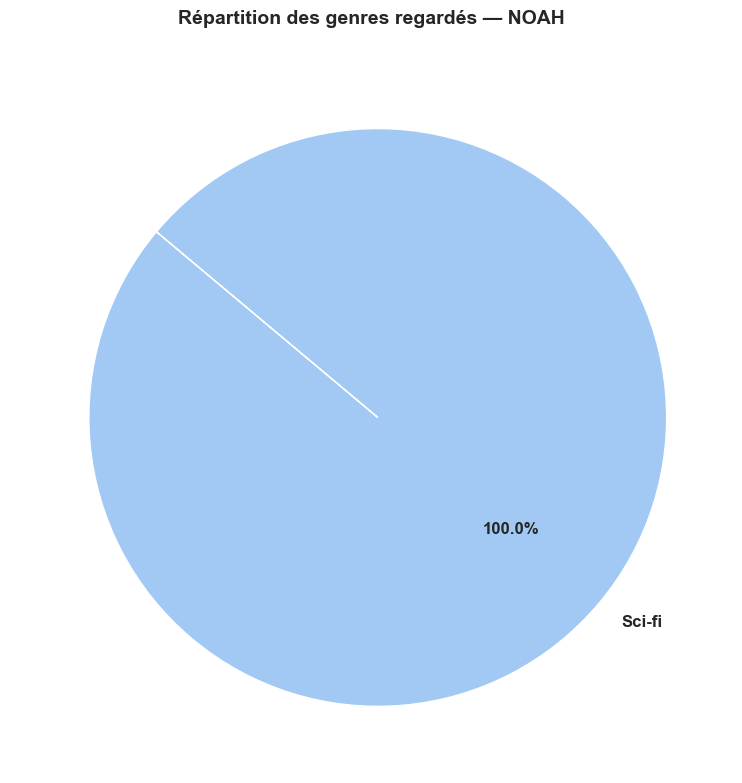

In [ ]:
#Affichage d'un diagramme circulaire pour visualiser la répartition des genres regardés par un utilisateur
def afficher_diagramme_circulaire(id_utilisateur, donnees_utilisateurs):
    if id_utilisateur not in donnees_utilisateurs:
        print("Utilisateur introuvable.")
        return
        
    historique = donnees_utilisateurs[id_utilisateur]["watch_history"]
    compte_genres = {}
    
    for f in historique:
        genres = f["genre"] if isinstance(f["genre"], list) else [f["genre"]]
        for g in genres:
            compte_genres[g] = compte_genres.get(g, 0) + 1
            
    # Configuration esthétique du graphique
    plt.figure(figsize=(8, 8))
    sns.set_theme(style="whitegrid")
    
    # Palette de couleurs élégante et espacement des parts (explode)
    couleurs = sns.color_palette("pastel")[0:len(compte_genres)]
    explode = [0.03] * len(compte_genres)
    
    plt.pie(
        compte_genres.values(), 
        labels=[g.capitalize() for g in compte_genres.keys()], 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=couleurs,
        explode=explode,
        textprops={'fontsize': 12, 'weight': 'bold'}
    )
    
    plt.title(f"Répartition des genres regardés — {donnees_utilisateurs[id_utilisateur]['name'].upper()}", fontsize=14, weight='bold', pad=20)
    plt.tight_layout()
    plt.show()

# Affichage pour l'utilisateur 1
afficher_diagramme_circulaire(1, utilisateurs_structures)

### Évolution des notes au fil du temps (Graphique linéaire)

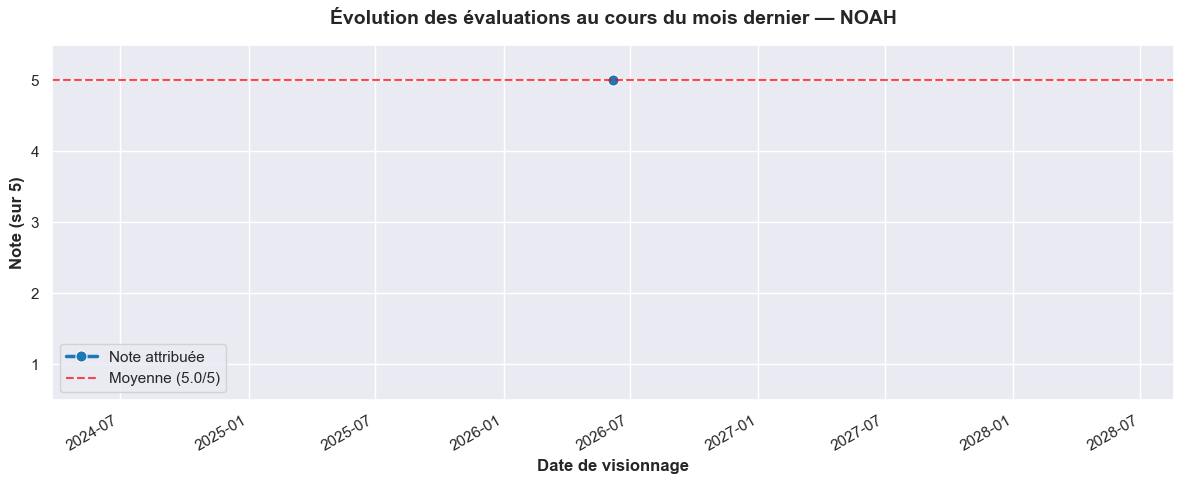

In [ ]:
#Affichage d'un graphique linéaire pour visualiser l'évolution des notes attribuées par un utilisateur au fil du temps
def afficher_evolution_notes(id_utilisateur, donnees_utilisateurs):
    if id_utilisateur not in donnees_utilisateurs:
        print("Utilisateur introuvable.")
        return
        
    historique = donnees_utilisateurs[id_utilisateur]["watch_history"]
    
    # Création d'une plage de dates s'étalant sur les 30 derniers jours
    dates_simulees = pd.date_range(end=pd.Timestamp.now(), periods=len(historique), freq='D')
    
    # Construction d'un DataFrame temporaire pour trier et ordonner proprement
    donnees_temporelles = []
    for i, f in enumerate(historique):
        donnees_temporelles.append({
            "Date": dates_simulees[i],
            "Note": f["rating"],
            "Film": f["movie"]
        })
        
    df_visu = pd.DataFrame(donnees_temporelles).sort_values(by="Date")
    
    # Configuration du graphique linéaire
    plt.figure(figsize=(12, 5))
    sns.set_theme(style="darkgrid")
    
    # Tracé de la ligne avec marqueurs
    sns.lineplot(
        data=df_visu, 
        x="Date", 
        y="Note", 
        marker="o", 
        markersize=8, 
        color="#1f77b4", 
        linewidth=2.5,
        label="Note attribuée"
    )
    
    # Ajout d'une ligne pointillée représentant la moyenne de l'utilisateur
    note_moyenne = df_visu["Note"].mean()
    plt.axhline(note_moyenne, color="red", linestyle="--", alpha=0.7, label=f"Moyenne ({note_moyenne:.1f}/5)")
    
    # Personnalisation des axes et labels
    plt.title(f"Évolution des évaluations au cours du mois dernier — {donnees_utilisateurs[id_utilisateur]['name'].upper()}", fontsize=14, weight='bold', pad=15)
    plt.xlabel("Date de visionnage", fontsize=12, weight='bold')
    plt.ylabel("Note (sur 5)", fontsize=12, weight='bold')
    
    plt.ylim(0.5, 5.5)
    plt.legend(loc="lower left", fontsize=11)
    plt.gcf().autofmt_xdate() # Pivotement automatique des dates sur l'axe X pour éviter les collisions
    plt.tight_layout()
    plt.show()

# Affichage pour l'utilisateur 1
afficher_evolution_notes(1, utilisateurs_structures)